<a href="https://colab.research.google.com/github/Nimishp97/MAJOR-PROJECT/blob/main/Customer_Feedback_Sentiment_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Sentiment Analysis Engine
### Dataset: `sample30.csv` | 30,000 Product Reviews
**Stack:** Python · NLTK · TF-IDF · Logistic Regression · scikit-learn

---
## 📋 Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Text Preprocessing](#4-text-preprocessing)
5. [TF-IDF Feature Engineering](#5-tf-idf-feature-engineering)
6. [Logistic Regression — Training](#6-logistic-regression--training)
7. [Model Evaluation](#7-model-evaluation)
8. [Feature Importance & Interpretability](#8-feature-importance--interpretability)
9. [Handling Class Imbalance](#9-handling-class-imbalance)
10. [Hyperparameter Tuning](#10-hyperparameter-tuning)
11. [Live Prediction Interface](#11-live-prediction-interface)
12. [Save & Load Model](#12-save--load-model)
13. [Concept Summary Cheat Sheet](#13-concept-summary-cheat-sheet)


---
## 1. Setup & Imports
> Install and import every library used in this notebook.

In [1]:
# Install dependencies
# !pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud imbalanced-learn

import re, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
for r in ['punkt','stopwords','wordnet','omw-1.4','punkt_tab']:
    nltk.download(r, quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, f1_score, recall_score, precision_score
)
from sklearn.preprocessing import LabelEncoder
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('All libraries ready.')
print(f'  numpy   {np.__version__} | pandas {pd.__version__} | sklearn {__import__("sklearn").__version__}')


All libraries ready.
  numpy   2.0.2 | pandas 2.2.2 | sklearn 1.6.1


---
## 2. Data Loading & Exploration

**About this dataset:**
- 30,000 real product reviews (Amazon/Walmart)
- **Target:** `user_sentiment` → Positive / Negative
- **Feature:** `reviews_text` → free-form review text
- Supporting columns: `brand`, `reviews_rating`, `reviews_doRecommend`


In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────
# In Colab: upload sample30.csv first, or mount Google Drive
DATA_PATH = '/content/sample30.csv'   # change path if needed

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Shape: 9,957 rows x 15 columns


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


In [3]:
# ── Column overview: types, nulls, missing% ───────────────────────────────
info = pd.DataFrame({
    'dtype':      df.dtypes,
    'non_null':   df.notnull().sum(),
    'missing':    df.isnull().sum(),
    'missing_%':  (df.isnull().mean()*100).round(2)
})
print(info.to_string())


                       dtype  non_null  missing  missing_%
id                    object      9957        0       0.00
brand                 object      9957        0       0.00
categories            object      9957        0       0.00
manufacturer          object      9957        0       0.00
name                  object      9957        0       0.00
reviews_date          object      9943       14       0.14
reviews_didPurchase   object      3659     6298      63.25
reviews_doRecommend   object      9408      549       5.51
reviews_rating         int64      9957        0       0.00
reviews_text          object      9957        0       0.00
reviews_title         object      9900       57       0.57
reviews_userCity      object      1254     8703      87.41
reviews_userProvince  object        35     9922      99.65
reviews_username      object      9914       43       0.43
user_sentiment        object      9956        1       0.01


In [4]:
# ── Target distribution ───────────────────────────────────────────────────
print('Target: user_sentiment')
print(df['user_sentiment'].value_counts())
pos_pct = df['user_sentiment'].eq('Positive').mean()*100
print(f'\nClass ratio  Positive:{pos_pct:.1f}%  Negative:{100-pos_pct:.1f}%')
print(f'Missing labels: {df["user_sentiment"].isna().sum()}')

# ── Drop rows with missing text or label ──────────────────────────────────
df.dropna(subset=['reviews_text','user_sentiment'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nClean dataset: {len(df):,} rows')


Target: user_sentiment
user_sentiment
Positive    8799
Negative    1157
Name: count, dtype: int64

Class ratio  Positive:88.4%  Negative:11.6%
Missing labels: 1

Clean dataset: 9,956 rows


---
## 3. Exploratory Data Analysis (EDA)

> Understand the data before modelling. Look for patterns, imbalances, and quirks.

**Key questions:**
- How imbalanced is our target?
- Does star rating correlate with sentiment label?
- How long are the reviews?
- Which brands dominate the dataset?
- What words appear most in each sentiment class?


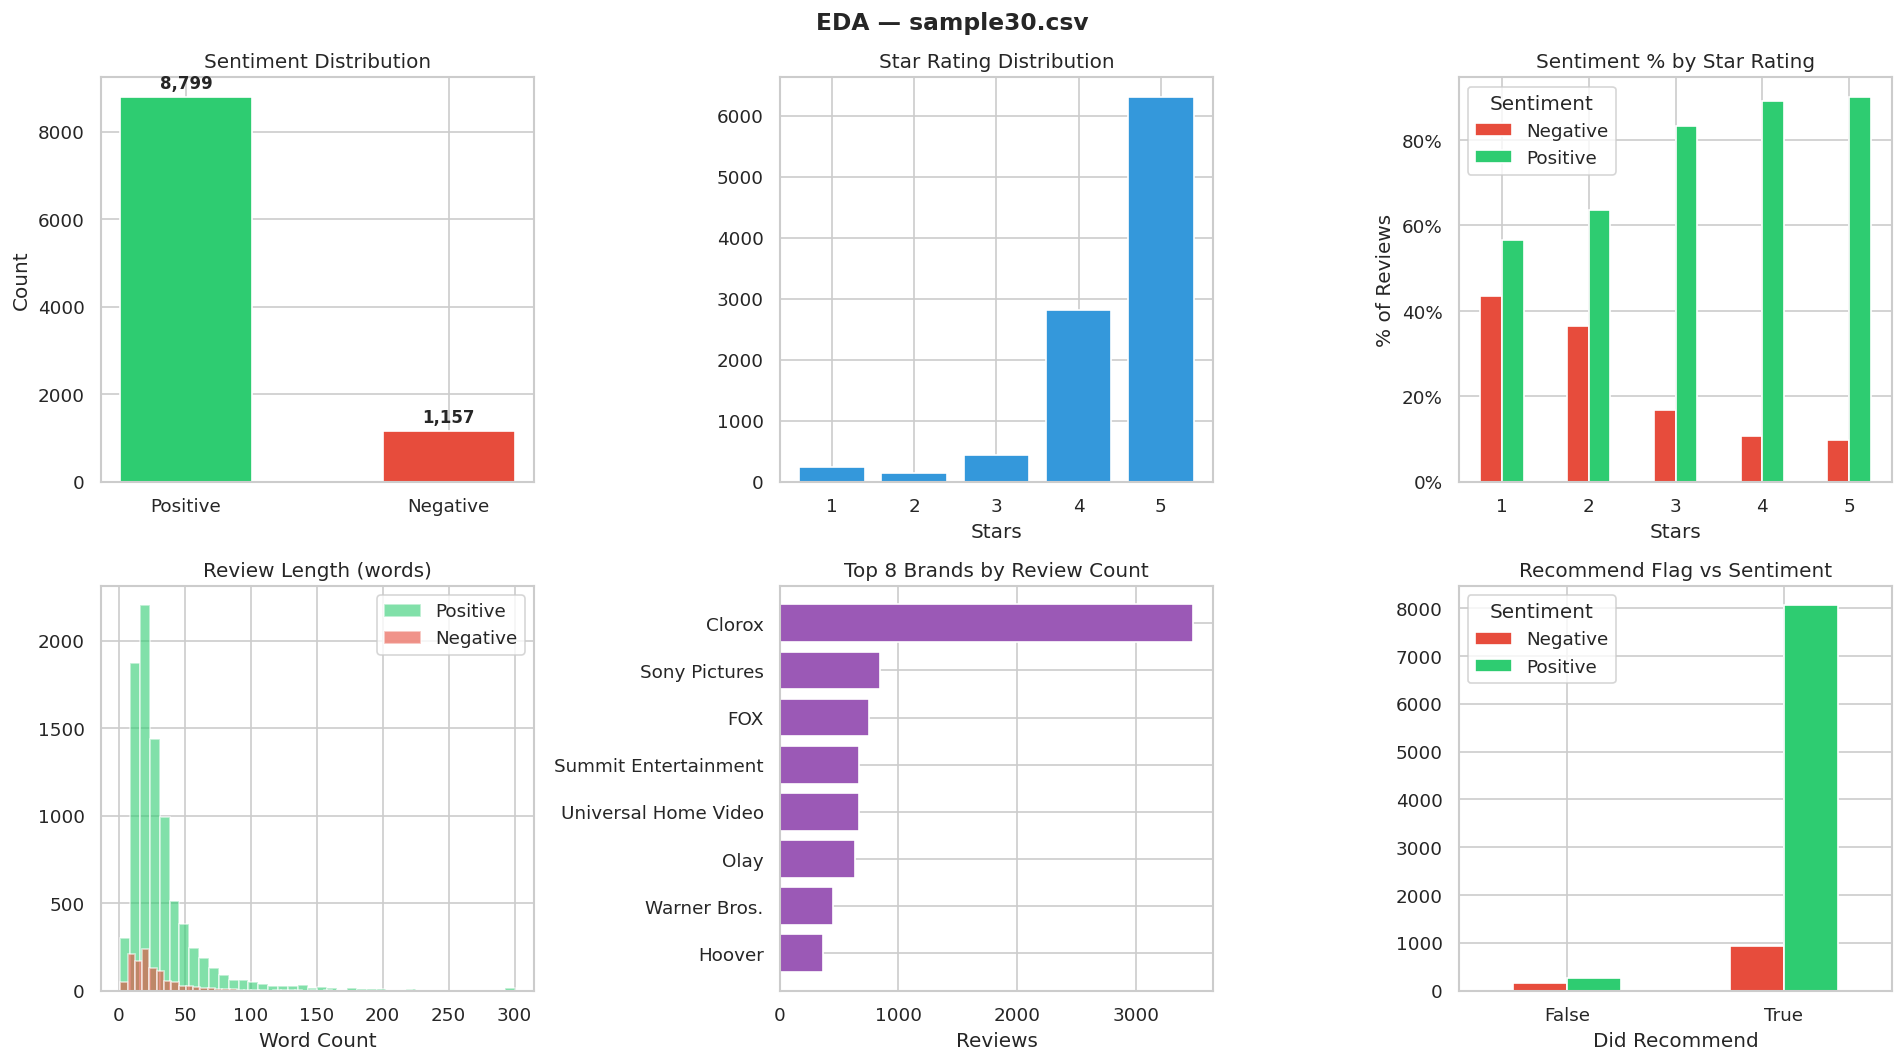

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — sample30.csv', fontsize=14, fontweight='bold')

# 1. Sentiment distribution
ax = axes[0,0]
vc = df['user_sentiment'].value_counts()
bars = ax.bar(vc.index, vc.values, color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Sentiment Distribution'); ax.set_ylabel('Count')

# 2. Rating distribution
ax = axes[0,1]
rvc = df['reviews_rating'].value_counts().sort_index()
ax.bar(rvc.index, rvc.values, color='#3498db', edgecolor='white')
ax.set_title('Star Rating Distribution'); ax.set_xlabel('Stars')

# 3. Rating vs Sentiment
ax = axes[0,2]
ct = pd.crosstab(df['reviews_rating'], df['user_sentiment'], normalize='index')*100
ct.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
ax.set_title('Sentiment % by Star Rating')
ax.set_xlabel('Stars'); ax.set_ylabel('% of Reviews')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Sentiment')

# 4. Review length
ax = axes[1,0]
df['text_len'] = df['reviews_text'].str.split().str.len()
for sent, color in [('Positive','#2ecc71'),('Negative','#e74c3c')]:
    ax.hist(df.loc[df['user_sentiment']==sent,'text_len'].clip(upper=300),
            bins=40, alpha=0.6, color=color, label=sent, edgecolor='white')
ax.set_title('Review Length (words)'); ax.set_xlabel('Word Count'); ax.legend()

# 5. Top brands
ax = axes[1,1]
top_brands = df['brand'].value_counts().head(8)
ax.barh(top_brands.index[::-1], top_brands.values[::-1], color='#9b59b6', edgecolor='white')
ax.set_title('Top 8 Brands by Review Count'); ax.set_xlabel('Reviews')

# 6. Recommend vs Sentiment
ax = axes[1,2]
rec = df.dropna(subset=['reviews_doRecommend'])
ct2 = pd.crosstab(rec['reviews_doRecommend'], rec['user_sentiment'])
ct2.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
ax.set_title('Recommend Flag vs Sentiment'); ax.set_xlabel('Did Recommend'); ax.legend(title='Sentiment')

plt.tight_layout()
plt.show()


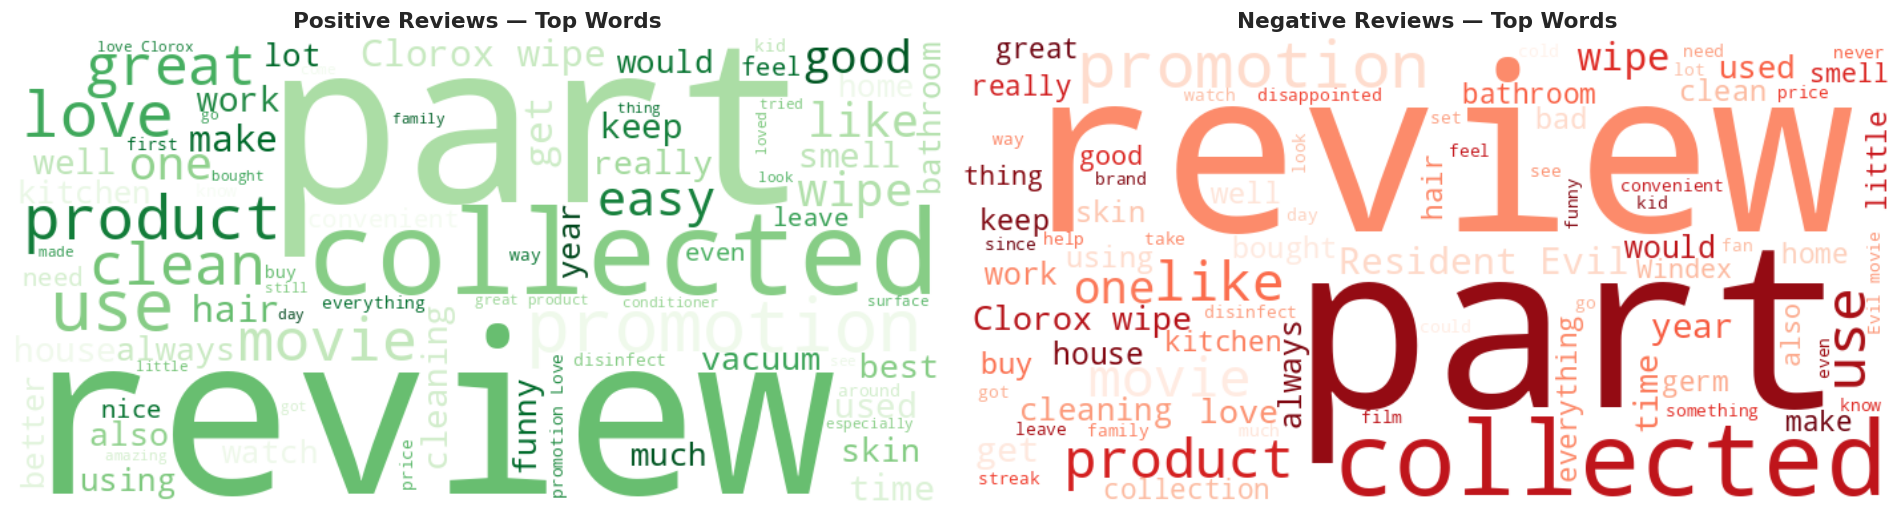

In [6]:
# ── Word Clouds per Sentiment ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, sentiment, cmap in [(axes[0],'Positive','Greens'),(axes[1],'Negative','Reds')]:
    corpus = ' '.join(df.loc[df['user_sentiment']==sentiment, 'reviews_text'].dropna())
    wc = WordCloud(width=700, height=350, background_color='white', colormap=cmap,
                   max_words=80, stopwords=set(stopwords.words('english'))).generate(corpus)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(f'{sentiment} Reviews — Top Words', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 4. Text Preprocessing

Raw text cannot feed directly into ML. We convert it into a clean, standardised string of meaningful tokens.

### Pipeline
| Step | Example | Reason |
|------|---------|--------|
| Lowercase | `Amazing` → `amazing` | Unify case |
| Remove noise | `<b>100%!!</b>` → `` | Strip HTML, digits, symbols |
| Tokenize | `I love this` → `['I','love','this']` | Split into tokens |
| Remove stop words | `['I','love','this']` → `['love']` | Drop low-info words |
| Lemmatize | `running` → `run`, `studies` → `study` | Merge word forms |

**Lemmatize vs Stem:**
- Lemmatization uses WordNet vocabulary → grammatically correct roots
- Stemming (Porter) just cuts suffixes → faster but cruder (`happily→happili`)
- We use **Lemmatization** throughout


In [7]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

def preprocess(text: str) -> str:
    '''
    NLP preprocessing pipeline:
    1. Lowercase
    2. Remove HTML / URLs / non-alpha chars
    3. Tokenize with NLTK word_tokenize
    4. Drop stop words and tokens < 3 chars
    5. Lemmatize with WordNetLemmatizer
    Returns cleaned string ready for TF-IDF.
    '''
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)         # strip HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)  # strip URLs
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Demo
demo = [
    'This product is ABSOLUTELY amazing!!! Best buy ever :)',
    'Terrible... broke within 2 days. DO NOT BUY. Returning immediately.',
    '<b>Great item</b>, arrived quickly. 100%% satisfied.'
]
for t in demo:
    print(f'RAW:    {t}')
    print(f'CLEAN:  {preprocess(t)}')
    print()


RAW:    This product is ABSOLUTELY amazing!!! Best buy ever :)
CLEAN:  product absolutely amazing best buy ever

RAW:    Terrible... broke within 2 days. DO NOT BUY. Returning immediately.
CLEAN:  terrible broke within day buy returning immediately

RAW:    <b>Great item</b>, arrived quickly. 100%% satisfied.
CLEAN:  great item arrived quickly satisfied



In [8]:
# Apply to full dataset (~60 seconds)
print('Preprocessing 30k reviews...')
df['clean_text'] = df['reviews_text'].apply(preprocess)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
df['clean_len'] = df['clean_text'].str.split().str.len()
print(f'Done! {len(df):,} reviews remaining.')
print(f'Avg words before cleaning: {df["text_len"].mean():.0f}')
print(f'Avg tokens after cleaning: {df["clean_len"].mean():.0f}')


Preprocessing 30k reviews...
Done! 9,953 reviews remaining.
Avg words before cleaning: 32
Avg tokens after cleaning: 16


---
## 5. TF-IDF Feature Engineering

ML models need numbers, not text. TF-IDF converts each review into a **numeric vector**.

### The Math
```
TF(word, doc)    = count(word in doc) / len(doc)
IDF(word)        = log( N_total_docs / N_docs_with_word )
TF-IDF(word,doc) = TF x IDF
```

**Intuition:** A word gets a HIGH weight when it appears often in *this* document but rarely across all documents.
- `'the'` → appears everywhere → near-zero IDF → ignored
- `'excellent'` → appears in few docs → high IDF → informative

**Result:** Each review = a sparse vector of ~10,000 dimensions. Matrix shape: `(n_reviews, vocab_size)`.

### Key Parameters
| Parameter | Setting | Why |
|-----------|---------|-----|
| `max_features=10000` | Top 10k words | Controls memory |
| `ngram_range=(1,2)` | Unigrams + bigrams | Captures 'not good', 'very bad' |
| `min_df=3` | Ignore words in < 3 docs | Removes typos/noise |
| `max_df=0.90` | Ignore words in > 90% docs | Removes corpus stop words |
| `sublinear_tf=True` | Use log(1+TF) | Compresses high-freq word counts |


In [9]:
# Encode target: Negative=0, Positive=1
le = LabelEncoder()
df['label'] = le.fit_transform(df['user_sentiment'])
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df['clean_text']
y = df['label']

# Train/Test split — stratify keeps same class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train positive rate: {y_train.mean()*100:.1f}%  Test positive rate: {y_test.mean()*100:.1f}%')


Label encoding: {'Negative': np.int64(0), 'Positive': np.int64(1)}
Train: 7,962 | Test: 1,991
Train positive rate: 88.4%  Test positive rate: 88.4%


In [10]:
# Fit TF-IDF on TRAIN only — never on test (that would be data leakage)
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True,
    strip_accents='unicode',
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform on TRAIN
X_test_tfidf  = tfidf.transform(X_test)         # transform only on TEST

vocab = tfidf.get_feature_names_out()
print(f'Vocabulary size    : {len(vocab):,} tokens')
print(f'Train matrix shape : {X_train_tfidf.shape}')
print(f'Test  matrix shape : {X_test_tfidf.shape}')
sparsity = 1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])
print(f'Matrix sparsity    : {sparsity*100:.2f}%  (most entries are zero)')


Vocabulary size    : 8,764 tokens
Train matrix shape : (7962, 8764)
Test  matrix shape : (1991, 8764)
Matrix sparsity    : 99.77%  (most entries are zero)


In [11]:
# Show top TF-IDF tokens for a sample review
idx = 5
sample_vec = X_train_tfidf[idx].toarray()[0]
top_idx = sample_vec.argsort()[::-1][:12]
print(f'Review excerpt: {X_train.iloc[idx][:90]}...')
print(f'\n{"Token":<25} TF-IDF Weight')
print('-' * 40)
for i in top_idx:
    if sample_vec[i] > 0:
        print(f'{vocab[i]:<25} {sample_vec[i]:.4f}')


Review excerpt: love product everyday chore quick wipe ups always sink...

Token                     TF-IDF Weight
----------------------------------------
product everyday          0.4327
chore                     0.3948
quick wipe                0.3826
ups                       0.3252
sink                      0.3117
everyday                  0.2868
love product              0.2508
quick                     0.2384
always                    0.2133
wipe                      0.1525
product                   0.1394
love                      0.1323


---
## 6. Logistic Regression — Training

### The Math
```
z     = w0 + w1*x1 + w2*x2 + ... + wn*xn   (linear combination of TF-IDF weights)
P(y=1|x) = sigmoid(z) = 1 / (1 + exp(-z))  -> probability in (0,1)
label    = 1 if P >= threshold else 0

Loss = -[ y*log(P) + (1-y)*log(1-P) ]       (binary cross-entropy)
Training: minimize Loss via L-BFGS optimizer
```

### Regularization
Regularization prevents overfitting by penalizing large weights:
- **L2 (Ridge):** `Loss += lambda * sum(w_i^2)` — shrinks all weights toward 0
- **L1 (Lasso):** `Loss += lambda * sum(|w_i|)` — drives some weights to exactly 0 (feature selection)
- `C = 1/lambda`: lower C = stronger penalty = simpler model


In [12]:
# Train Logistic Regression
lr = LogisticRegression(
    C=1.0,                    # regularization (higher = less)
    penalty='l2',             # Ridge regularization
    solver='lbfgs',           # L-BFGS optimizer, efficient for high-dim NLP
    max_iter=1000,
    class_weight='balanced',  # auto-upweight minority class
    random_state=42,
)

lr.fit(X_train_tfidf, y_train)
print('Model trained!')
print(f'  Iterations used : {lr.n_iter_[0]}')
print(f'  Converged       : {lr.n_iter_[0] < 1000}')


Model trained!
  Iterations used : 19
  Converged       : True


In [13]:
# 5-Fold Cross Validation
# Trains/tests on 5 different data partitions -> more reliable than one split
cv_acc = cross_val_score(
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42),
    X_train_tfidf, y_train, cv=5, scoring='accuracy', n_jobs=-1
)
cv_auc = cross_val_score(
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42),
    X_train_tfidf, y_train, cv=5, scoring='roc_auc', n_jobs=-1
)
print(f'CV Accuracy : {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'CV ROC-AUC  : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')
print(f'Folds (acc) : {[round(s,4) for s in cv_acc]}')


CV Accuracy : 0.8838 +/- 0.0083
CV ROC-AUC  : 0.9275 +/- 0.0078
Folds (acc) : [np.float64(0.8901), np.float64(0.8801), np.float64(0.8719), np.float64(0.8957), np.float64(0.8813)]


---
## 7. Model Evaluation

### Metrics Explained
| Metric | Formula | Best for |
|--------|---------|----------|
| **Accuracy** | (TP+TN)/total | Balanced classes |
| **Precision** | TP/(TP+FP) | When false positives are costly |
| **Recall** | TP/(TP+FN) | When missing positives is costly |
| **F1-Score** | 2*P*R/(P+R) | Imbalanced classes |
| **ROC-AUC** | Area under ROC | Best general-purpose metric |

> ⚠️ With 89% positive labels, predicting *always positive* gives 89% accuracy. Check F1 and AUC to catch this.

**Confusion Matrix terms:**
- **TP**: predicted Positive, actually Positive
- **FP**: predicted Positive, actually Negative (false alarm)
- **FN**: predicted Negative, actually Positive (missed)
- **TN**: predicted Negative, actually Negative


In [14]:
y_pred = lr.predict(X_test_tfidf)
y_prob = lr.predict_proba(X_test_tfidf)[:,1]  # P(Positive)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('='*50)
print(f'  Accuracy : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  ROC-AUC  : {auc:.4f}')
print('='*50)
print()
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))


  Accuracy : 0.8960  (89.6%)
  ROC-AUC  : 0.9355

              precision    recall  f1-score   support

    Negative       0.53      0.81      0.64       231
    Positive       0.97      0.91      0.94      1760

    accuracy                           0.90      1991
   macro avg       0.75      0.86      0.79      1991
weighted avg       0.92      0.90      0.90      1991



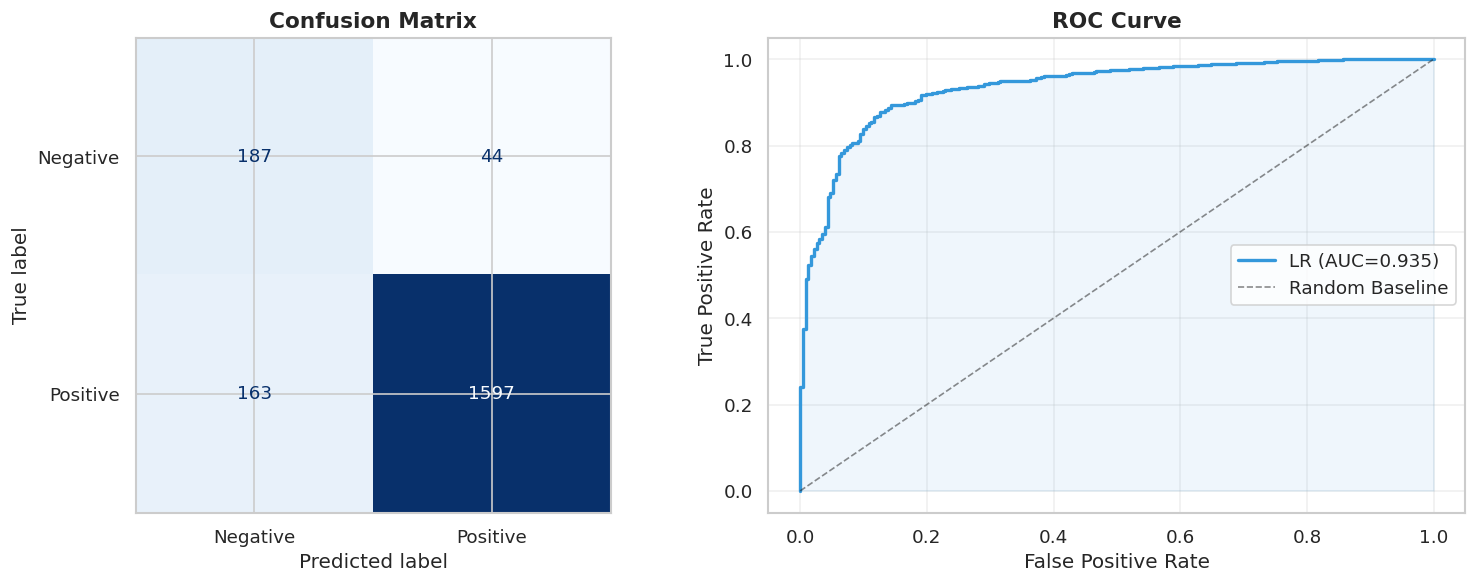

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, lw=2, color='#3498db', label=f'LR (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random Baseline')
ax.fill_between(fpr, tpr, alpha=0.08, color='#3498db')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


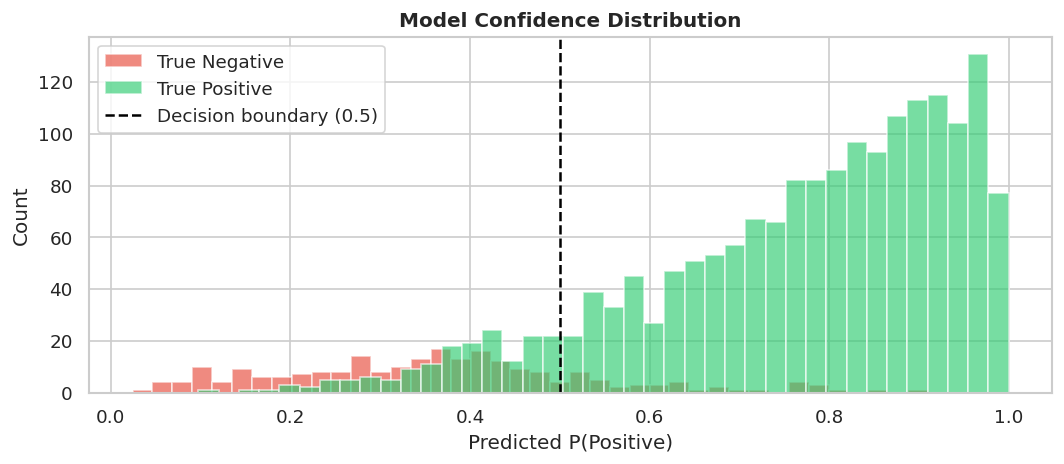

In [16]:
# Confidence distribution — well-separated curves = confident model
fig, ax = plt.subplots(figsize=(9,4))
y_test_arr = np.array(y_test)
ax.hist(y_prob[y_test_arr==0], bins=40, alpha=0.65, color='#e74c3c', label='True Negative', edgecolor='white')
ax.hist(y_prob[y_test_arr==1], bins=40, alpha=0.65, color='#2ecc71', label='True Positive', edgecolor='white')
ax.axvline(0.5, color='black', lw=1.5, ls='--', label='Decision boundary (0.5)')
ax.set_xlabel('Predicted P(Positive)'); ax.set_ylabel('Count')
ax.set_title('Model Confidence Distribution', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


---
## 8. Feature Importance & Interpretability

One of the biggest advantages of Logistic Regression over deep learning: **full interpretability**.

Every TF-IDF feature has a learned coefficient `w_i`:
- `w_i > 0` → this word **predicts Positive** sentiment
- `w_i < 0` → this word **predicts Negative** sentiment
- `|w_i|` → strength of that prediction

This lets you audit the model: *why did it classify this review as negative?*


In [17]:
# Top positive and negative feature weights
coef = lr.coef_[0]
n = 20
top_pos_idx = np.argsort(coef)[-n:][::-1]
top_neg_idx = np.argsort(coef)[:n]

print(f'POSITIVE INDICATORS ({n} strongest):')
for i in top_pos_idx:
    bar = chr(9608)*min(30, int(abs(coef[i])*15))
    print(f'  {vocab[i]:<30} {coef[i]:+.3f}  {bar}')

print(f'\nNEGATIVE INDICATORS ({n} strongest):')
for i in top_neg_idx:
    bar = chr(9608)*min(30, int(abs(coef[i])*15))
    print(f'  {vocab[i]:<30} {coef[i]:+.3f}  {bar}')


POSITIVE INDICATORS (20 strongest):
  great                          +11.219  ██████████████████████████████
  love                           +9.179  ██████████████████████████████
  good                           +7.489  ██████████████████████████████
  best                           +6.284  ██████████████████████████████
  easy                           +6.100  ██████████████████████████████
  clean                          +5.707  ██████████████████████████████
  loved                          +4.023  ██████████████████████████████
  awesome                        +3.913  ██████████████████████████████
  nice                           +3.689  ██████████████████████████████
  excellent                      +3.535  ██████████████████████████████
  many                           +3.484  ██████████████████████████████
  action                         +3.447  ██████████████████████████████
  amazing                        +3.403  ██████████████████████████████
  quick                    

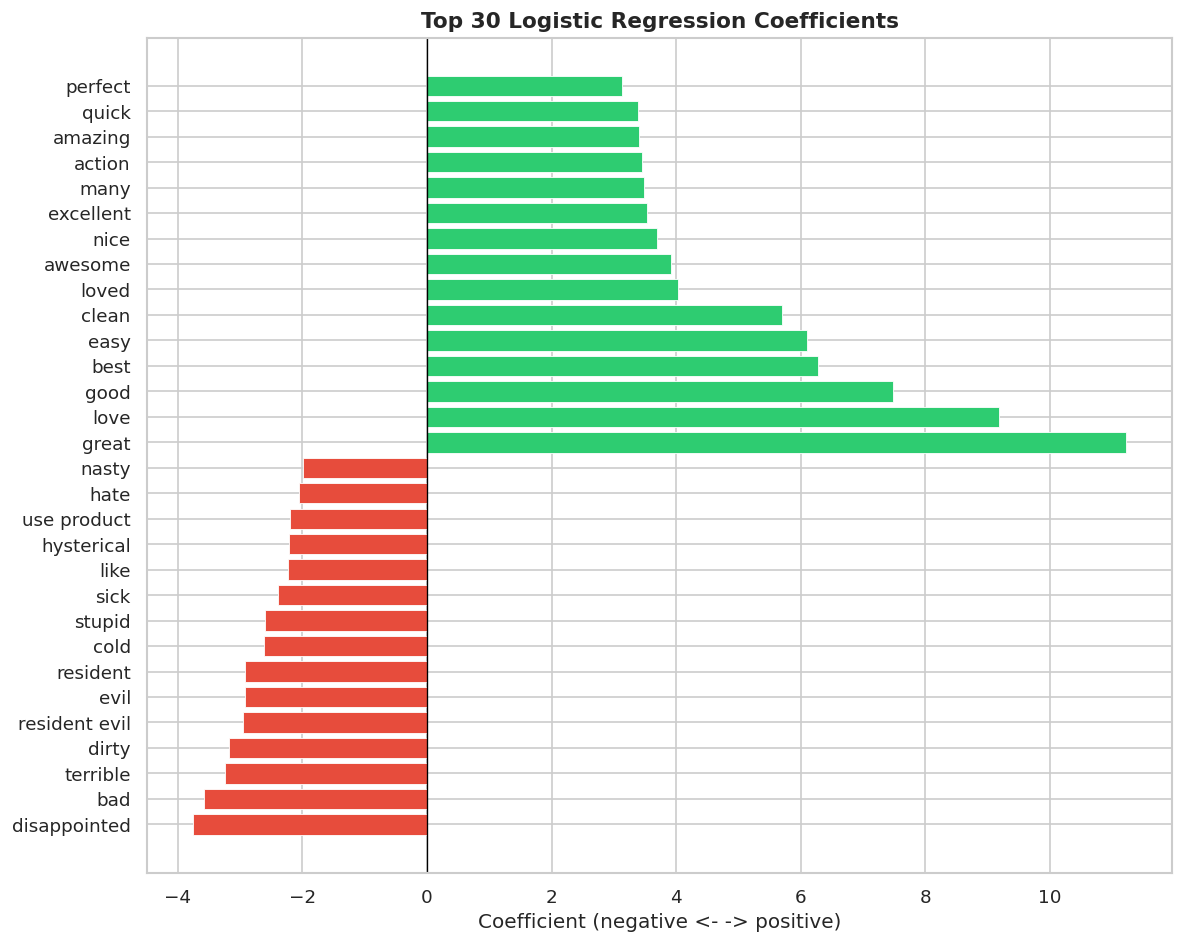

In [18]:
# Coefficient bar chart
n = 15
top_pos = [(vocab[i], coef[i]) for i in np.argsort(coef)[-n:][::-1]]
top_neg = [(vocab[i], coef[i]) for i in np.argsort(coef)[:n]]
combined = top_neg + top_pos
words_  = [w for w,_ in combined]
coefs_  = [c for _,c in combined]
colors_ = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs_]

fig, ax = plt.subplots(figsize=(10,8))
ax.barh(words_, coefs_, color=colors_, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 30 Logistic Regression Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (negative <- -> positive)')
plt.tight_layout(); plt.show()


In [19]:
# Explain a single prediction
def explain_prediction(text: str, n_top=8):
    '''
    Show which words in a review most influenced the prediction.
    Uses the TF-IDF weight * LR coefficient for each token.
    '''
    cleaned = preprocess(text)
    vec = tfidf.transform([cleaned]).toarray()[0]
    contributions = vec * coef           # element-wise: tfidf_weight * lr_weight
    top_idx = np.abs(contributions).argsort()[::-1][:n_top]

    prob = lr.predict_proba(tfidf.transform([cleaned]))[0]
    label = 'Positive' if prob[1] >= 0.5 else 'Negative'

    print(f'Text    : {text[:80]}')
    print(f'Label   : {label}  (P_pos={prob[1]:.3f}, P_neg={prob[0]:.3f})')
    print(f'\nTop contributing tokens:')
    print(f'  {"Token":<25} {"TF-IDF":>8}  {"LR Coef":>9}  {"Contribution":>12}  Direction')
    print('  ' + '-'*70)
    for i in top_idx:
        if vec[i] > 0:
            direction = '-> POS' if contributions[i] > 0 else '-> NEG'
            print(f'  {vocab[i]:<25} {vec[i]:>8.4f}  {coef[i]:>+9.4f}  {contributions[i]:>+12.4f}  {direction}')

explain_prediction('This product is absolutely outstanding, best thing I ever bought!')
print()
explain_prediction('Terrible quality, broke within two days. Complete waste of money.')


Text    : This product is absolutely outstanding, best thing I ever bought!
Label   : Positive  (P_pos=0.762, P_neg=0.238)

Top contributing tokens:
  Token                       TF-IDF    LR Coef  Contribution  Direction
  ----------------------------------------------------------------------
  best                        0.2042    +6.2844       +1.2832  -> POS
  bought                      0.2380    -1.5116       -0.3597  -> NEG
  absolutely                  0.2897    +0.9793       +0.2837  -> POS
  outstanding                 0.3717    +0.7289       +0.2710  -> POS
  thing                       0.2353    -0.6463       -0.1521  -> NEG
  best thing                  0.3930    +0.3240       +0.1273  -> POS
  product                     0.1334    +0.9245       +0.1234  -> POS
  ever                        0.2543    +0.4133       +0.1051  -> POS

Text    : Terrible quality, broke within two days. Complete waste of money.
Label   : Negative  (P_pos=0.261, P_neg=0.739)

Top contributing tok

---
## 9. Handling Class Imbalance

Our dataset: **89% Positive, 11% Negative**. This matters because:
- A model that predicts *always Positive* gets 89% accuracy — but is useless
- The model may learn to ignore the minority class entirely

### Strategies
1. `class_weight='balanced'` ✅ Already applied — re-weights the loss function
2. **Threshold tuning** — lower decision boundary to catch more negatives
3. **SMOTE** — synthesizes new minority-class samples (shown below)


In [20]:
# Strategy 1: class_weight — already baked in
from collections import Counter
counts = Counter(y_train)
total = len(y_train)
print('class_weight=balanced computes:')
for cls in sorted(counts):
    w = total / (2 * counts[cls])
    label = ['Negative','Positive'][cls]
    print(f'  Class {cls} ({label:8}): {counts[cls]:,} samples -> weight = {w:.2f}x')


class_weight=balanced computes:
  Class 0 (Negative): 925 samples -> weight = 4.30x
  Class 1 (Positive): 7,037 samples -> weight = 0.57x


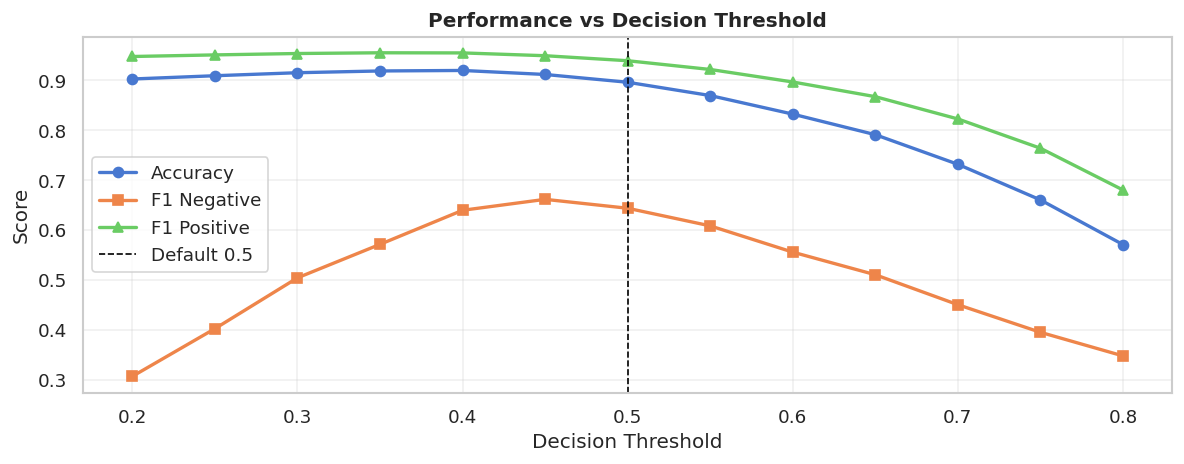

 threshold  accuracy  f1_negative  f1_positive  recall_neg
      0.20  0.902562     0.307143     0.947596    0.186147
      0.25  0.909091     0.402640     0.950802    0.264069
      0.30  0.915118     0.504399     0.953584    0.372294
      0.35  0.918634     0.571429     0.955050    0.467532
      0.40  0.919638     0.639640     0.954777    0.614719
      0.45  0.911602     0.661538     0.949162    0.744589
      0.50  0.896032     0.643718     0.939136    0.809524
      0.55  0.869412     0.608434     0.921640    0.874459
      0.60  0.832245     0.555851     0.896594    0.904762
      0.65  0.791060     0.510588     0.867178    0.939394
      0.70  0.731793     0.450617     0.822591    0.948052
      0.75  0.660472     0.395349     0.763966    0.956710
      0.80  0.571070     0.348092     0.680389    0.987013


In [21]:
# Strategy 2: Threshold tuning
thresholds = np.arange(0.20, 0.80, 0.05)
results = []
for t in thresholds:
    yp = (y_prob >= t).astype(int)
    results.append({
        'threshold':  round(t,2),
        'accuracy':   accuracy_score(y_test, yp),
        'f1_negative': f1_score(y_test, yp, pos_label=0),
        'f1_positive': f1_score(y_test, yp, pos_label=1),
        'recall_neg':  recall_score(y_test, yp, pos_label=0),
    })

res_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(res_df['threshold'], res_df['accuracy'],    label='Accuracy',     marker='o', lw=2)
ax.plot(res_df['threshold'], res_df['f1_negative'], label='F1 Negative',  marker='s', lw=2)
ax.plot(res_df['threshold'], res_df['f1_positive'], label='F1 Positive',  marker='^', lw=2)
ax.axvline(0.5, color='black', ls='--', lw=1, label='Default 0.5')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('Performance vs Decision Threshold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(res_df.to_string(index=False))


---
## 10. Hyperparameter Tuning with GridSearchCV

Instead of guessing the best hyperparameters, we search systematically.

**GridSearchCV:**
- Tries every combination in a grid
- Uses k-fold cross-validation for honest evaluation
- Returns the best parameter set

We wrap TF-IDF + LR in a **Pipeline** so:
1. TF-IDF is always fit only on the training fold
2. No data leakage between folds
3. Both steps tune together


In [22]:
# Pipeline: TF-IDF + Logistic Regression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, strip_accents='unicode', min_df=3)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

# Parameter grid — each combination is tested
# Note: (2 x 2 x 3) = 12 combos x 3-fold CV = 36 model fits
param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range':  [(1,1), (1,2)],
    'clf__C':              [0.1, 1.0, 5.0],
    'clf__penalty':        ['l2'],
}

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=3, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)  # raw text — Pipeline handles vectorizing
print('Grid search complete!')
print(f'Best ROC-AUC (CV): {grid_search.best_score_:.4f}')
print(f'Best params:       {grid_search.best_params_}')


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Grid search complete!
Best ROC-AUC (CV): 0.9301
Best params:       {'clf__C': 5.0, 'clf__penalty': 'l2', 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}


In [23]:
# Evaluate best model on held-out test set
best_model  = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

print('Best Model — Test Set:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['Negative','Positive']))


Best Model — Test Set:
  Accuracy : 0.9001
  ROC-AUC  : 0.9410

              precision    recall  f1-score   support

    Negative       0.55      0.82      0.66       231
    Positive       0.97      0.91      0.94      1760

    accuracy                           0.90      1991
   macro avg       0.76      0.86      0.80      1991
weighted avg       0.92      0.90      0.91      1991



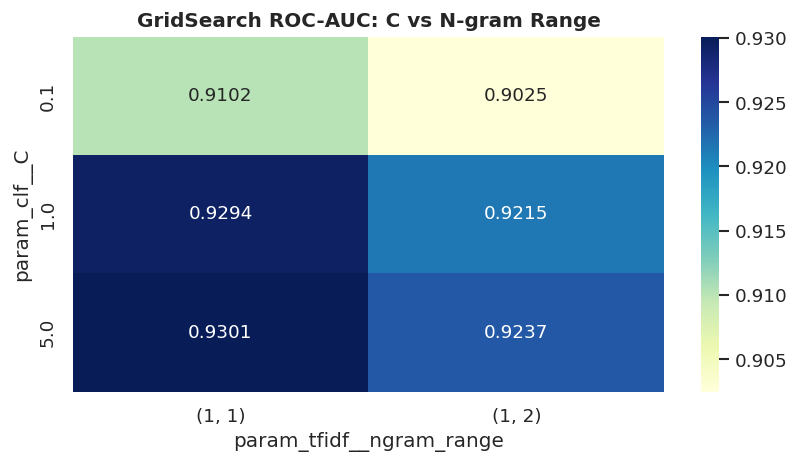

In [24]:
# GridSearch results heatmap
res_df_gs = pd.DataFrame(grid_search.cv_results_)
pivot = res_df_gs.pivot_table(
    index='param_clf__C',
    columns='param_tfidf__ngram_range',
    values='mean_test_score',
    aggfunc='max'
)
fig, ax = plt.subplots(figsize=(7,4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('GridSearch ROC-AUC: C vs N-gram Range', fontweight='bold')
plt.tight_layout(); plt.show()


---
## 11. Live Prediction Interface

Apply the trained model to any new review text.


In [25]:
def predict_sentiment(text, model=None, threshold=0.5):
    '''
    Predict sentiment for a single review.
    Args:
        text      : raw review string
        model     : trained Pipeline (default: best_model from GridSearch)
        threshold : P(Positive) cutoff (default 0.5)
    Returns:
        dict with label, confidence, prob breakdown, clean_text
    '''
    if model is None:
        model = best_model
    cleaned  = preprocess(text)
    proba    = model.predict_proba([cleaned])[0]
    label_id = int(proba[1] >= threshold)
    label    = ['Negative','Positive'][label_id]
    return {
        'label':         label,
        'confidence':    float(proba[label_id]),
        'prob_negative': float(proba[0]),
        'prob_positive': float(proba[1]),
        'clean_text':    cleaned,
    }

# Test cases
test_reviews = [
    'Absolutely love this! Best purchase I have made in years. Will buy again.',
    'Terrible quality. Broke within two days. Complete waste of money.',
    'It arrived on time. Packaging was fine. Does what it says.',
    'Not bad, but not amazing. Expected more for the price.',
    'Outstanding! Far exceeded my expectations. Customer service was incredible.',
]

print(f'{"REVIEW":<65} {"LABEL":<10} CONF   POS_PROB')
print('-'*100)
for rev in test_reviews:
    r = predict_sentiment(rev)
    emoji = 'POS' if r['label'] == 'Positive' else 'NEG'
    bar = chr(9619)*int(r['prob_positive']*20) + chr(9617)*(20-int(r['prob_positive']*20))
    print(f'[{emoji}] {rev[:62]:<63} {r["label"]:<10} {r["confidence"]:.1%}  [{bar}]')


REVIEW                                                            LABEL      CONF   POS_PROB
----------------------------------------------------------------------------------------------------
[POS] Absolutely love this! Best purchase I have made in years. Will  Positive   99.9%  [▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░]
[NEG] Terrible quality. Broke within two days. Complete waste of mon  Negative   88.2%  [▓▓░░░░░░░░░░░░░░░░░░]
[POS] It arrived on time. Packaging was fine. Does what it says.      Positive   58.7%  [▓▓▓▓▓▓▓▓▓▓▓░░░░░░░░░]
[NEG] Not bad, but not amazing. Expected more for the price.          Negative   58.5%  [▓▓▓▓▓▓▓▓░░░░░░░░░░░░]
[NEG] Outstanding! Far exceeded my expectations. Customer service wa  Negative   50.3%  [▓▓▓▓▓▓▓▓▓░░░░░░░░░░░]


In [26]:
# Batch prediction
def predict_batch(texts, model=None, threshold=0.5):
    results = [predict_sentiment(t, model, threshold) for t in texts]
    out = pd.DataFrame(results)
    out.insert(0, 'text', texts)
    return out

sample_texts = df['reviews_text'].sample(6, random_state=7).tolist()
batch_out = predict_batch(sample_texts)
batch_out[['text','label','confidence','prob_positive']].to_string()


'                                                                                                                                                                               text     label  confidence  prob_positive\n0                                                                                                         This is a fantastic movie filled with great humor and action! A must see!  Positive    0.998113       0.998113\n1                                                                                                                    Funny, Funny, Funny! A guys movie for sure! not a date movie!!  Positive    0.947640       0.947640\n2  Love this product! it cleans great and it smells good too!! We use this all the time and will continue to but it at the store! This review was collected as part of a promotion.  Positive    0.999952       0.999952\n3                                                                                                       A unique design. Four i

---
## 12. Save & Load Model


In [27]:
# Save trained pipeline
MODEL_PATH = 'sentiment_model.pkl'
joblib.dump(best_model, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

# Load it back
loaded_model = joblib.load(MODEL_PATH)
print(f'Model loaded from {MODEL_PATH}')

# Verify
test = 'This shampoo is absolutely wonderful, best hair product ever!'
r = predict_sentiment(test, model=loaded_model)
print(f'\nTest: {test}')
print(f'Prediction: {r["label"]}  ({r["confidence"]:.1%} confidence)')


Model saved to sentiment_model.pkl
Model loaded from sentiment_model.pkl

Test: This shampoo is absolutely wonderful, best hair product ever!
Prediction: Positive  (99.9% confidence)


In [28]:
# Final Model Summary
bp = grid_search.best_params_
print('='*55)
print('  FINAL MODEL SUMMARY')
print('='*55)
print(f'  Dataset          : sample30.csv ({len(df):,} reviews)')
print(f'  Vocabulary size  : {bp["tfidf__max_features"]:,}')
print(f'  N-gram range     : {bp["tfidf__ngram_range"]}')
print(f'  Regularization C : {bp["clf__C"]}')
print(f'  Best CV AUC      : {grid_search.best_score_:.4f}')
print(f'  Test Accuracy    : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Test ROC-AUC     : {roc_auc_score(y_test, y_prob_best):.4f}')
print('='*55)


  FINAL MODEL SUMMARY
  Dataset          : sample30.csv (9,953 reviews)
  Vocabulary size  : 5,000
  N-gram range     : (1, 1)
  Regularization C : 5.0
  Best CV AUC      : 0.9301
  Test Accuracy    : 0.9001
  Test ROC-AUC     : 0.9410


---
## 13. Concept Summary Cheat Sheet

### Text Preprocessing
| Term | Definition |
|------|------------|
| **Tokenization** | Splitting text into individual word units |
| **Stop Words** | High-frequency, low-signal words removed from analysis |
| **Lemmatization** | Reducing words to dictionary form via grammar (run←running) |
| **Stemming** | Crude suffix-cutting (faster, less accurate than lemma) |

### TF-IDF
| Term | Formula | Intuition |
|------|---------|----------|
| TF | count(w,doc)/len(doc) | How often word appears *here* |
| IDF | log(N/df(w)) | How rare the word is everywhere |
| TF-IDF | TF × IDF | Informative words score high |
| Bigram | 'not good' | Two-word features for negation/intensifiers |
| Sparsity | ~99% zeros | Most docs lack most vocabulary words |

### Logistic Regression
| Term | Meaning |
|------|----------|
| sigmoid σ(z) | Maps z → (0,1) probability |
| coef_ | Learned weight per feature; positive = predicts Positive |
| C param | Inverse regularization: higher = less penalty |
| L2 Ridge | Shrinks all weights toward zero |
| L1 Lasso | Zeros out some weights (sparse feature selection) |
| Cross-entropy | Loss function: -[y*log(p) + (1-y)*log(1-p)] |

### Evaluation
| Metric | Formula | Use when |
|--------|---------|----------|
| Accuracy | (TP+TN)/N | Balanced classes |
| Precision | TP/(TP+FP) | FP are costly |
| Recall | TP/(TP+FN) | FN are costly |
| F1 | 2PR/(P+R) | Imbalanced classes |
| ROC-AUC | Area under ROC | Best overall |

### Pipeline Architecture
```
Raw Text
   |
   v preprocess()                 lowercase, clean, tokenize, lemmatize
Clean Text
   |
   v TfidfVectorizer              fit ONLY on train split (no leakage!)
Sparse Matrix (n_reviews x 10000)
   |
   v LogisticRegression           class_weight=balanced for imbalance
P(Positive) -> label
```
